In [43]:
import os
import pandas as pd
import numpy as np
import random
from scipy.stats import truncnorm

In [44]:
this_dir = os.getcwd()
work_dir = os.path.dirname(this_dir)
write_dir = "/mnt/storage/ldl_linguistics/PhonGen2025_diag_new/data_NTNORM/"    # NOTE: NT = natural, NORM = normalized (using Global Min-Max)
# Shuhao used to write this as adaptive path retrieval, but I have to use hardcode the path for now since we are generating on Lab computer but running on Faculty server. --- IGNORE ---

# NOTE: SC = shifted center, meaning that the centers of the two dimensions are not the same. But the variance in this version is smaller. 

In [45]:
vowel_means = [0, 0, 0, 400, 400, 80, 200, 1000, 1500, 2460]
cons_means = [-1, -1, 60, 200, 0, 0, 0, 0, 0, 0]
all_means = vowel_means + cons_means + vowel_means
# cog, fri_dur, fri_int, tot_dur, voc_dur, voc_int, f0, f1, f2, f3
# 0 = not used, -1 = must fill in in later codes

vowel_stds = [0, 0, 0, 0, 0, 0, 10, 50, 75, 123]
cons_stds = [400, 20, 3, 0, 0, 0, 0, 0, 0, 0]
all_sds = vowel_stds + cons_stds + vowel_stds


any_mins = [2000, 0, 0, 0, 0, 0, 50, 200, 500, 2500]
any_maxs = [12000, 500, 140, 500, 500, 140, 500, 1200, 3500, 5000]
print(all_means)
print(all_sds)
print(any_mins)
print(any_maxs)

[0, 0, 0, 400, 400, 80, 200, 1000, 1500, 2460, -1, -1, 60, 200, 0, 0, 0, 0, 0, 0, 0, 0, 0, 400, 400, 80, 200, 1000, 1500, 2460]
[0, 0, 0, 0, 0, 0, 10, 50, 75, 123, 400, 20, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 10, 50, 75, 123]
[2000, 0, 0, 0, 0, 0, 50, 200, 500, 2500]
[12000, 500, 140, 500, 500, 140, 500, 1200, 3500, 5000]


In [46]:
def generate_data_for_one_dim(mean, std, a=-2, b=2, sample_size=8000): 
    # NOTE: it turns out that truncnorm can take std = 0, then we can just fill in everything directly. 
    dist = truncnorm(a, b, loc = mean, scale = std)
    return dist.rvs(size = sample_size)

In [48]:
condition = "test_natural"
data_dir = os.path.join(work_dir, f'data_{condition}')
os.makedirs(data_dir, exist_ok=True)

np.random.seed(42)

consonant_list = ['ts', 'tc', 's', 'c']
consonant_cog = [4600, 9600, 4600, 9600]
consonant_fd = [50, 50, 180, 180]
train_refs = [1, 2, 4, 3]

# no. of tokens for each word
sample_size = 8000

metadata = []

for index in range (4):
    consonant = consonant_list[index]
    cog = consonant_cog[index]
    fri_dur = consonant_fd[index]
    train_ref = train_refs[index]

    vowel = 'a'
    word = vowel + consonant + vowel

    c_f_means = np.array([cog, fri_dur])
    cons_means_actual = np.concatenate((c_f_means, np.array(cons_means[2:])))  # cog, fri_dur are replaced by the specific values for each consonant, but the rest are the same across all consonants.
    cons_stds_actual = np.array(cons_stds)

    consonants = np.zeros((sample_size, len(cons_means_actual)))
    for i in range(len(cons_means_actual)): # NOTE: this only takes care of the first two dimensions
        consonants[:, i] = generate_data_for_one_dim(cons_means_actual[i], cons_stds_actual[i], sample_size=sample_size)
    
    vowel_means_actual = np.array(vowel_means)
    vowel_stds_actual = np.array(vowel_stds)

    vowels = np.zeros((sample_size, len(vowel_means_actual)))
    for i in range(len(vowel_means_actual)):
        vowels[:, i] = generate_data_for_one_dim(vowel_means_actual[i], vowel_stds_actual[i], sample_size=sample_size)

    subdata_dir = os.path.join(data_dir, word)
    os.makedirs(subdata_dir, exist_ok=True)

    vowels = vowels[:, np.newaxis, :]
    consonants = consonants[:, np.newaxis, :]

    all_vcvs = np.concatenate([vowels, consonants, vowels], axis=1)
    all_mins = np.array([any_mins, any_mins, any_mins])
    all_maxs = np.array([any_maxs, any_maxs, any_maxs])

    norm_all_vcvs = (all_vcvs - all_mins) / (all_maxs - all_mins)

    for i in range(sample_size):
        uid = word + f'_{i+1:04d}'
        filename = f'{uid}.npy'
        save_path = os.path.join(subdata_dir, filename)
        vcv = norm_all_vcvs[i]
        np.save(save_path, vcv)

        # save_path_rel = os.path.relpath(save_path, start=work_dir)
        save_path_rel = os.path.join(write_dir, f'data_{condition}', word, filename)
        metadata.append({
            'uid': uid,
            'path': save_path_rel,
            'cog': vcv[1][0],
            'fri_dur': vcv[1][1],
            'word': word,
            'consonant': consonant,
            'vowel': vowel,
            'train': train_ref
        })

csv_name = f'metadata_{condition}.csv'
csv_path = os.path.join(data_dir, csv_name)
metaframe = pd.DataFrame(metadata)
metaframe.to_csv(csv_path, index=False)


In [ ]:
condition = "train_natural"
data_dir = os.path.join(work_dir, f'data_{condition}')
os.makedirs(data_dir, exist_ok=True)

np.random.seed(42)

consonant_list = ['ts', 'c']
consonant_cog = [4600, 9600]
consonant_fd = [50, 180]
train_refs = [1, 3]

# no. of tokens for each word
sample_size = 8000

metadata = []

for index in range (2):
    consonant = consonant_list[index]
    cog = consonant_cog[index]
    fri_dur = consonant_fd[index]
    train_ref = train_refs[index]

    vowel = 'a'
    word = vowel + consonant + vowel

    c_f_means = np.array([cog, fri_dur])
    cons_means_actual = np.concatenate((c_f_means, np.array(cons_means[2:])))  # cog, fri_dur are replaced by the specific values for each consonant, but the rest are the same across all consonants.
    cons_stds_actual = np.array(cons_stds)

    consonants = np.zeros((sample_size, len(cons_means_actual)))
    for i in range(len(cons_means_actual)): # NOTE: this only takes care of the first two dimensions
        consonants[:, i] = generate_data_for_one_dim(cons_means_actual[i], cons_stds_actual[i], sample_size=sample_size)
    
    vowel_means_actual = np.array(vowel_means)
    vowel_stds_actual = np.array(vowel_stds)

    vowels = np.zeros((sample_size, len(vowel_means_actual)))
    for i in range(len(vowel_means_actual)):
        vowels[:, i] = generate_data_for_one_dim(vowel_means_actual[i], vowel_stds_actual[i], sample_size=sample_size)

    subdata_dir = os.path.join(data_dir, word)
    os.makedirs(subdata_dir, exist_ok=True)

    vowels = vowels[:, np.newaxis, :]
    consonants = consonants[:, np.newaxis, :]

    all_vcvs = np.concatenate([vowels, consonants, vowels], axis=1)
    all_mins = np.array([any_mins, any_mins, any_mins])
    all_maxs = np.array([any_maxs, any_maxs, any_maxs])

    norm_all_vcvs = (all_vcvs - all_mins) / (all_maxs - all_mins)

    for i in range(sample_size):
        uid = word + f'_{i+1:04d}'
        filename = f'{uid}.npy'
        save_path = os.path.join(subdata_dir, filename)
        vcv = norm_all_vcvs[i]
        np.save(save_path, vcv)

        # save_path_rel = os.path.relpath(save_path, start=work_dir)
        save_path_rel = os.path.join(write_dir, f'data_{condition}', word, filename)
        metadata.append({
            'uid': uid,
            'path': save_path_rel,
            'cog': vcv[1][0],
            'fri_dur': vcv[1][1],
            'word': word,
            'consonant': consonant,
            'vowel': vowel,
            'train': train_ref
        })

csv_name = f'metadata_{condition}.csv'
csv_path = os.path.join(data_dir, csv_name)
metaframe = pd.DataFrame(metadata)
metaframe.to_csv(csv_path, index=False)

In [50]:
# x = '/mnt/ldl_linguistics/PhonGen2025_diag_new/data/data_test_equal/atsa/atsa_0001.npy'

# # insert after /mnt/ "storage/"
# x.replace('/mnt/', '/mnt/storage/')

## Visualize dataset

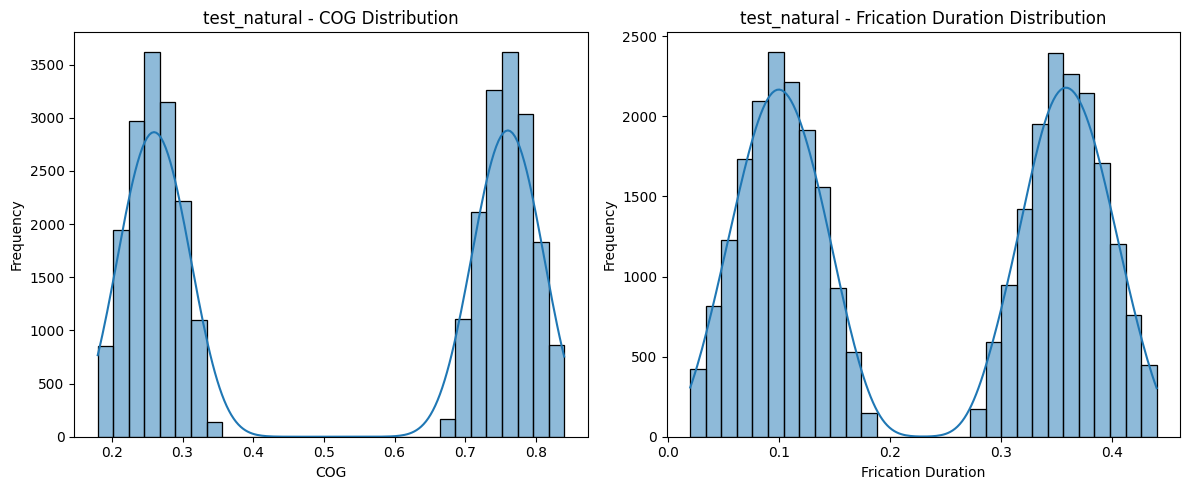

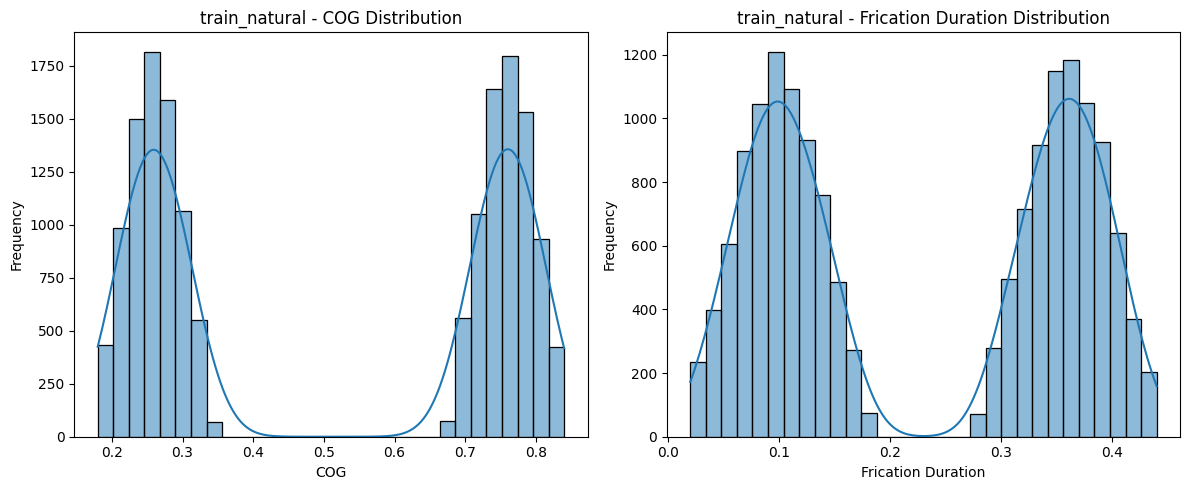

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

CONDITION_LIST = ["test_natural", "train_natural"]
ROOT_DIR = "./../"

for condition in CONDITION_LIST: 
    meta_path = os.path.join(ROOT_DIR, f'data_{condition}', f'metadata_{condition}.csv')
    metaframe = pd.read_csv(meta_path)

    # plot the distribution of cog and fri_dur for each condition
    # imported related libraries
    # plot the distribution of cog and fri_dur for each condition
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(metaframe['cog'], bins=30, kde=True)
    plt.title(f'{condition} - COG Distribution')
    plt.xlabel('COG')
    plt.ylabel('Frequency')
    plt.subplot(1, 2, 2)
    sns.histplot(metaframe['fri_dur'], bins=30, kde=True)
    plt.title(f'{condition} - Frication Duration Distribution')
    plt.xlabel('Frication Duration')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

In [52]:
condition = "test_natural"
np.random.seed(42)

consonant_list = ['ts', 'tc', 's', 'c']
consonant_cog = [4600, 9600, 4600, 9600]
consonant_fd = [50, 50, 180, 180]
train_refs = [1, 2, 4, 3]

# no. of tokens for each word
sample_size = 8000

vcv_dict = {}

for index in range (4):
    consonant = consonant_list[index]
    cog = consonant_cog[index]
    fri_dur = consonant_fd[index]
    train_ref = train_refs[index]

    vowel = 'a'
    word = vowel + consonant + vowel

    c_f_means = np.array([cog, fri_dur])
    cons_means_actual = np.concatenate((c_f_means, np.array(cons_means[2:])))  # cog, fri_dur are replaced by the specific values for each consonant, but the rest are the same across all consonants.
    cons_stds_actual = np.array(cons_stds)

    consonants = np.zeros((sample_size, len(cons_means_actual)))
    for i in range(len(cons_means_actual)): # NOTE: this only takes care of the first two dimensions
        consonants[:, i] = generate_data_for_one_dim(cons_means_actual[i], cons_stds_actual[i], sample_size=sample_size)
    
    vowel_means_actual = np.array(vowel_means)
    vowel_stds_actual = np.array(vowel_stds)

    vowels = np.zeros((sample_size, len(vowel_means_actual)))
    for i in range(len(vowel_means_actual)):
        vowels[:, i] = generate_data_for_one_dim(vowel_means_actual[i], vowel_stds_actual[i], sample_size=sample_size)

    subdata_dir = os.path.join(data_dir, word)
    os.makedirs(subdata_dir, exist_ok=True)

    vowels = vowels[:, np.newaxis, :]
    consonants = consonants[:, np.newaxis, :]

    all_vcvs = np.concatenate([vowels, consonants, vowels], axis=1)
    all_mins = np.array([any_mins, any_mins, any_mins])
    all_maxs = np.array([any_maxs, any_maxs, any_maxs])

    norm_all_vcvs = (all_vcvs - all_mins) / (all_maxs - all_mins)

    vcv_dict[word] = norm_all_vcvs


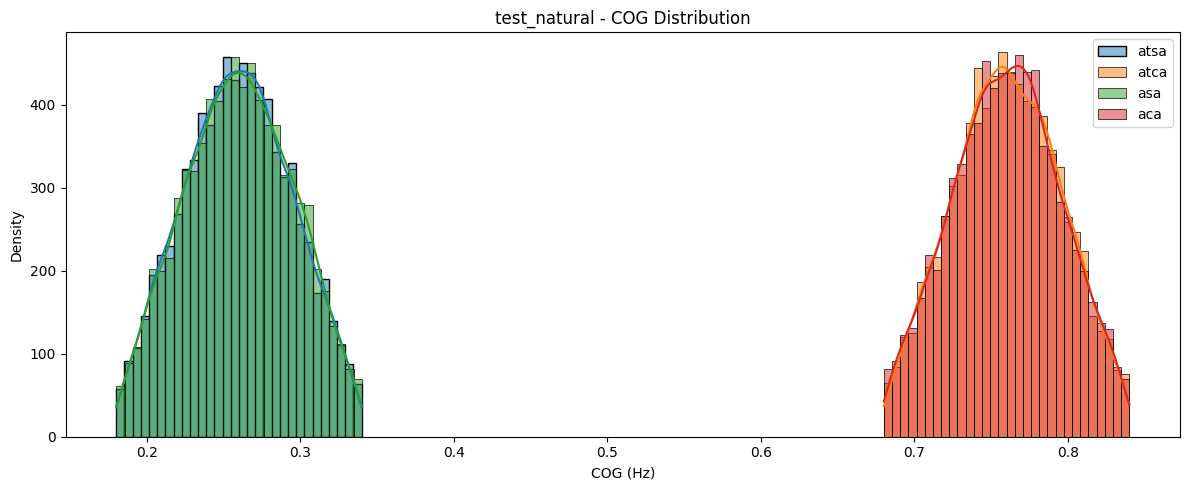

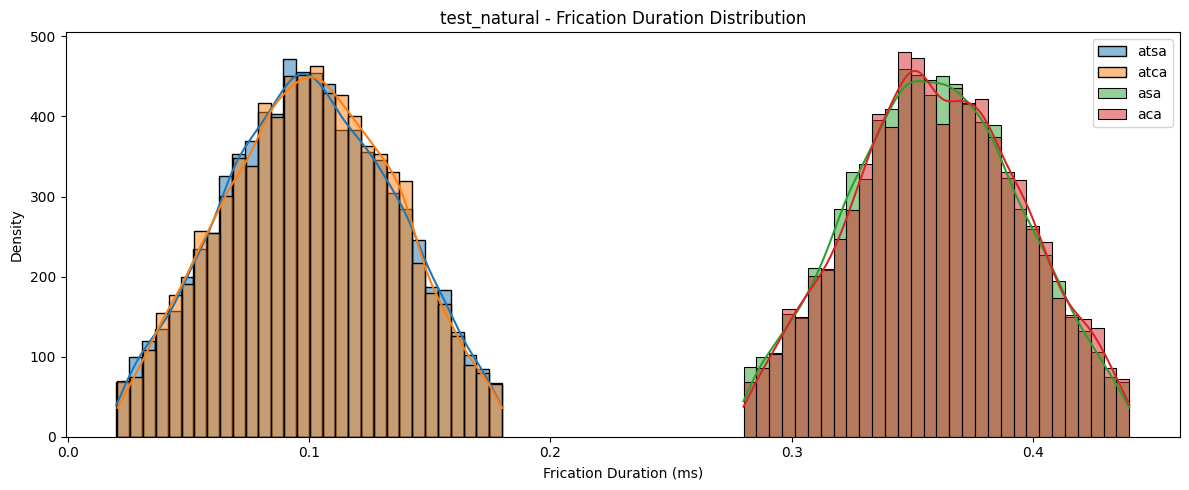

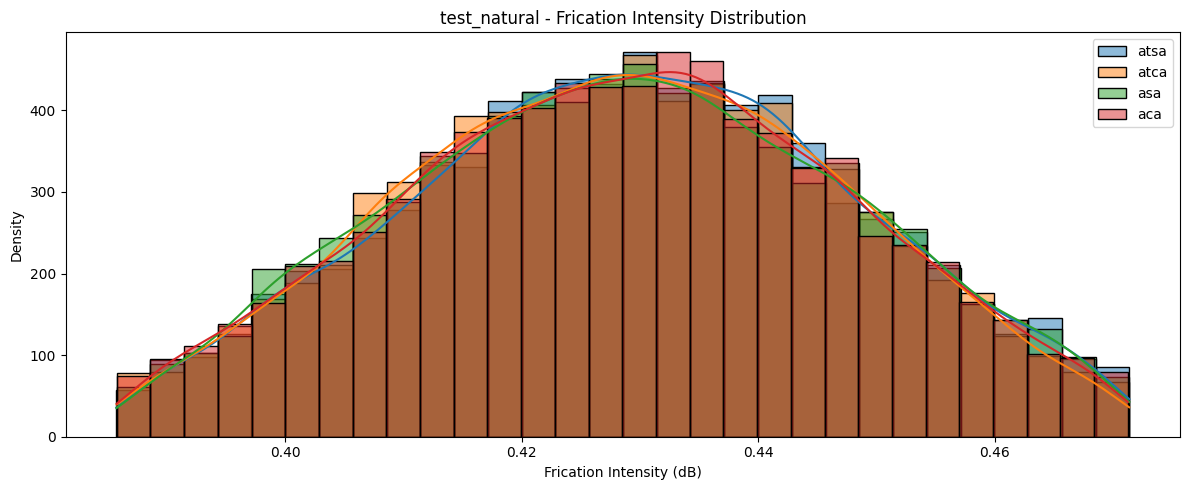

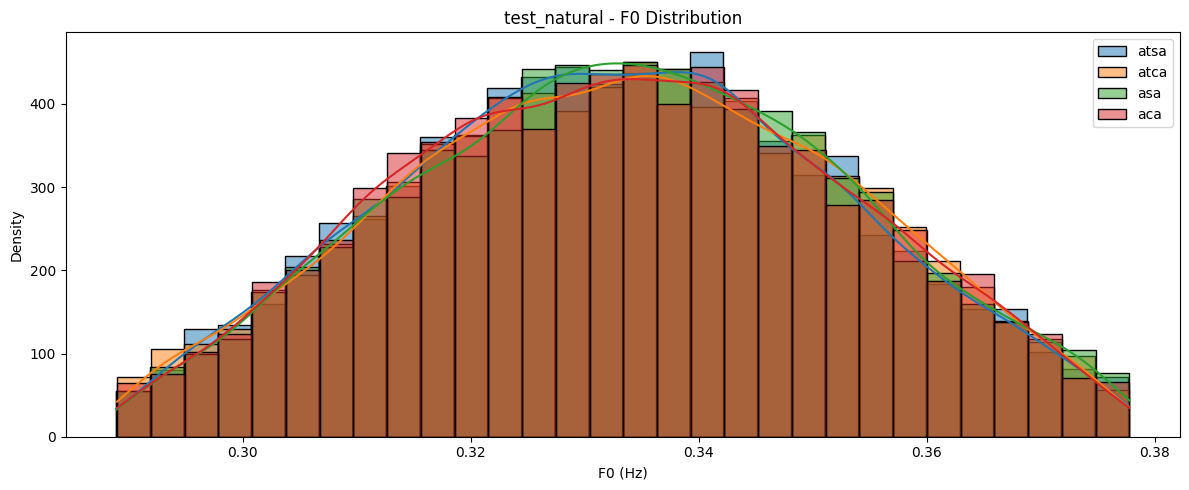

In [69]:
# plot the distribution of cog and fri_dur for all four words (words together, plot separate by dimension like cog or fri_dur)
plt.figure(figsize=(12, 5))
for word in vcv_dict:
    # bar plot and kde plot together
    sns.histplot(vcv_dict[word][:, 1, 0], bins=30, kde=True, label=word)  # cog is the first dimension of the consonant part
    # sns.kdeplot(vcv_dict[word][:, 1, 0], label=word)  # cog is the first dimension of the consonant part
plt.title(f'{condition} - COG Distribution')
plt.xlabel('COG (Hz)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for word in vcv_dict: 
    sns.histplot(vcv_dict[word][:, 1, 1], bins=30, kde=True, label=word)  # fri_dur is the second dimension of the consonant part
    # sns.kdeplot(vcv_dict[word][:, 1, 1], label=word)  # fri_dur is the second dimension of the consonant part
plt.title(f'{condition} - Frication Duration Distribution')
plt.xlabel('Frication Duration (ms)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for word in vcv_dict: 
    sns.histplot(vcv_dict[word][:, 1, 2], bins=30, kde=True, label=word)  # fri_dur is the second dimension of the consonant part
    # sns.kdeplot(vcv_dict[word][:, 1, 2], label=word)  # fri_dur is the second dimension of the consonant part
plt.title(f'{condition} - Frication Intensity Distribution')
plt.xlabel('Frication Intensity (dB)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for word in vcv_dict: 
    sns.histplot(vcv_dict[word][:, 2, 6], bins=30, kde=True, label=word)  # fri_dur is the second dimension of the consonant part
    # sns.kdeplot(vcv_dict[word][:, 2, 6], label=word)  # fri_dur is the second dimension of the consonant part
plt.title(f'{condition} - F0 Distribution')
plt.xlabel('F0 (Hz)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

# Some Quick Notes

Becuase I am generating data here. I leave some notes here for future refernce: 
1. When generating data, just run through it. Changing vairance is done by changing `CONSONANT_/VOWEL_CONFIGURED_VARIANCE`. Changing mean is done in each condition separately. 
2. After generating the data, they will appear in the hyperdir of this dir. Need to put them all into a dir for transfering. 
3. Use `scp -r /mnt/data/Projects/XXX franklhtan@10.64.109.137:/nfs/ldl_linguistics/PhonGen2025_diag_new/` to transfer. XXX is the data collection name. This should be the same as configured in `write_dir = "/mnt/storage/ldl_linguistics/PhonGen2025_diag_new/XXX/"`. 